# 🧠 Alzheimer's Disease Detection — Complete Pipeline
## MRI Models (VGG19 | ResNet50 | EfficientNetB0) + Clinical Models (Random Forest | XGBoost | 1D-CNN) + Fusion
---
### 📌 Datasets Required (Add both before running):
- **MRI Images** → /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented
- **Clinical Data** → /kaggle/input/datasets/rabieelkharoua/alzheimers-disease-dataset
---

## 📦 Step 1: Import Libraries

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score)
import joblib

# XGBoost
from xgboost import XGBClassifier

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG19, ResNet50, EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from matplotlib.patches import Patch

print('TensorFlow:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)
print('All libraries imported ✅')

TensorFlow: 2.19.0
GPU available: True
All libraries imported ✅


## 📂 Step 2: Paths & Hyperparameters

In [10]:
# =============================================
# PATHS
# =============================================
MRI_BASE      = '/kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented/combined_images'
MRI_TRAIN     = MRI_BASE
MRI_TEST      = MRI_BASE
CLINICAL_PATH = '/kaggle/input/datasets/rabieelkharoua/alzheimers-disease-dataset/alzheimers_disease_data.csv'

SAVE_DIR = '/kaggle/working/saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32
EPOCHS       = 20
LR           = 1e-4
NUM_CLASSES  = 4
RANDOM_STATE = 42
MRI_CLASS_NAMES = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

print('MRI Base exists     :', os.path.exists(MRI_BASE))
print('Clinical CSV exists :', os.path.exists(CLINICAL_PATH))
print('Save dir            :', SAVE_DIR)

MRI Base exists     : True
Clinical CSV exists : True
Save dir            : /kaggle/working/saved_models


---
# 🖼️ PART A — MRI IMAGE MODELS
---

## 🔍 Step 3: Explore MRI Data

Train distribution:
  MildDemented: 10000 images
  ModerateDemented: 10000 images
  NonDemented: 12800 images
  VeryMildDemented: 11200 images

Test distribution:
  MildDemented: 10000 images
  ModerateDemented: 10000 images
  NonDemented: 12800 images
  VeryMildDemented: 11200 images


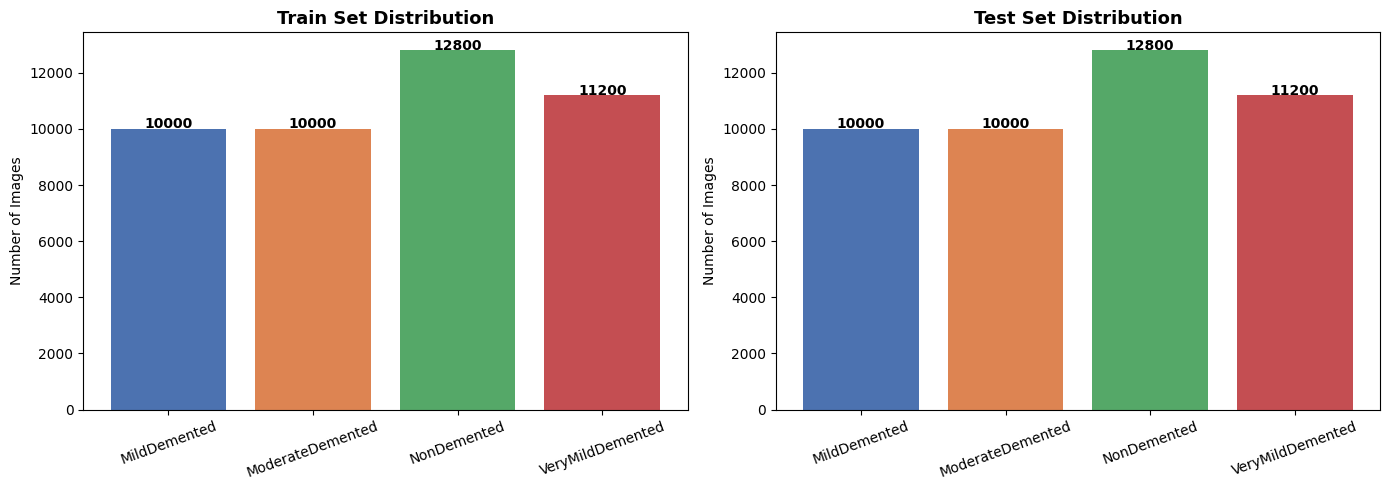

In [11]:
def count_images(path):
    counts = {}
    for cls in sorted(os.listdir(path)):
        cls_path = os.path.join(path, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len(os.listdir(cls_path))
    return counts

train_counts = count_images(MRI_TRAIN)
test_counts  = count_images(MRI_TEST)

print('Train distribution:')
for k, v in train_counts.items():
    print(f'  {k}: {v} images')
print('\nTest distribution:')
for k, v in test_counts.items():
    print(f'  {k}: {v} images')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (title, counts) in zip(axes, [('Train', train_counts), ('Test', test_counts)]):
    bars = ax.bar(counts.keys(), counts.values(),
                  color=['#4C72B0','#DD8452','#55A868','#C44E52'])
    ax.set_title(f'{title} Set Distribution', fontsize=13, fontweight='bold')
    ax.set_ylabel('Number of Images')
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, counts.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(val), ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/mri_distribution.png', dpi=150)
plt.show()

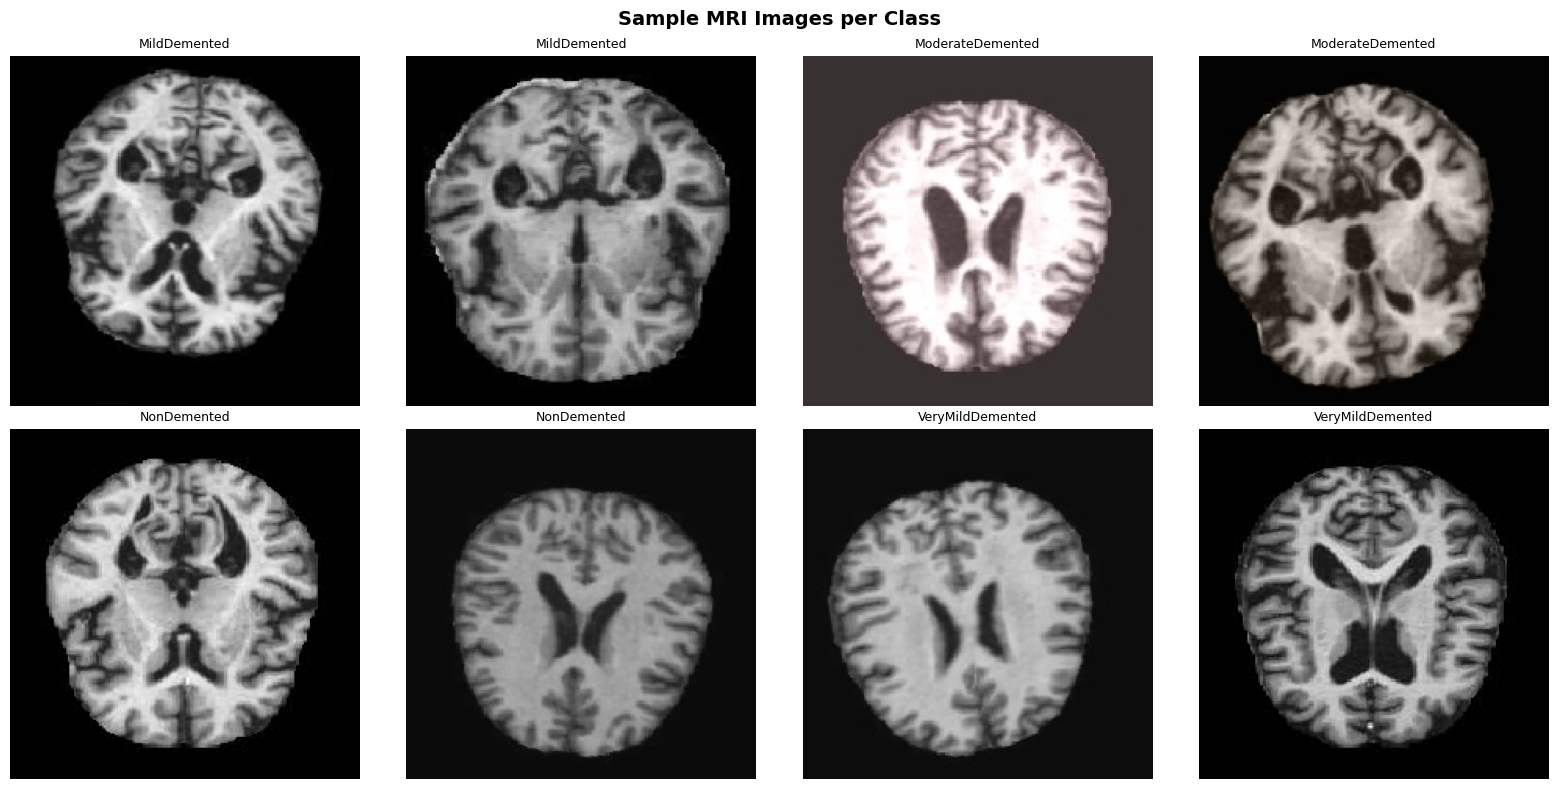

In [12]:
# Sample MRI images
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
idx = 0
for cls in sorted(os.listdir(MRI_TRAIN)):
    cls_path = os.path.join(MRI_TRAIN, cls)
    if os.path.isdir(cls_path):
        for img_name in os.listdir(cls_path)[:2]:
            img = load_img(os.path.join(cls_path, img_name), target_size=IMG_SIZE)
            axes[idx].imshow(img, cmap='gray')
            axes[idx].set_title(cls, fontsize=9)
            axes[idx].axis('off')
            idx += 1
plt.suptitle('Sample MRI Images per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/sample_images.png', dpi=150)
plt.show()

## ⚙️ Step 4: MRI Data Generators

In [13]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)
test_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    MRI_BASE, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True, seed=42
)
val_gen = train_datagen.flow_from_directory(
    MRI_BASE, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False, seed=42
)
test_gen = test_datagen.flow_from_directory(
    MRI_BASE, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False
)

print('Class indices:', train_gen.class_indices)
print(f'Train: {train_gen.samples}  |  Val: {val_gen.samples}  |  Test: {test_gen.samples}')

Found 35200 images belonging to 4 classes.
Found 8800 images belonging to 4 classes.
Found 8800 images belonging to 4 classes.
Class indices: {'MildDemented': 0, 'ModerateDemented': 1, 'NonDemented': 2, 'VeryMildDemented': 3}
Train: 35200  |  Val: 8800  |  Test: 8800


## 🛠️ Step 5: MRI Helper Functions

In [14]:
def get_callbacks(model_name):
    save_path = os.path.join(SAVE_DIR, f'{model_name}_best.keras')
    return [
        ModelCheckpoint(save_path, monitor='val_accuracy',
                        save_best_only=True, mode='max', verbose=1),
        EarlyStopping(monitor='val_accuracy', patience=5,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-7, verbose=1)
    ]

def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (tr, vl), title in zip(
        axes,
        [('accuracy','val_accuracy'), ('loss','val_loss')],
        ['Accuracy', 'Loss']
    ):
        ax.plot(history.history[tr], label=f'Train {title}', color='#2196F3')
        ax.plot(history.history[vl], label=f'Val {title}',   color='#F44336')
        ax.set_title(f'{model_name} — {title}', fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/{model_name}_history.png', dpi=150)
    plt.show()

def evaluate_mri_model(model, test_gen, model_name):
    test_gen.reset()
    loss, acc = model.evaluate(test_gen, verbose=0)
    print(f'\n🎯 {model_name} — Test Accuracy: {acc*100:.2f}%  |  Loss: {loss:.4f}')
    test_gen.reset()
    y_pred = np.argmax(model.predict(test_gen, verbose=0), axis=1)
    y_true = test_gen.classes
    labels = list(test_gen.class_indices.keys())
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=labels))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(f'{model_name} — Confusion Matrix', fontweight='bold')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/{model_name}_cm.png', dpi=150)
    plt.show()
    return acc

print('MRI helpers ready ✅')

MRI helpers ready ✅


## 🔵 MRI Model 1: VGG19

In [15]:
def build_vgg19(num_classes, lr):
    base = VGG19(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
    for layer in base.layers:
        layer.trainable = False
    for layer in base.layers[-4:]:
        layer.trainable = True
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inputs=base.input, outputs=output)
    model.compile(optimizer=Adam(lr), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

vgg19_model = build_vgg19(NUM_CLASSES, LR)
print(f'VGG19 built ✅  |  Params: {vgg19_model.count_params():,}')

VGG19 built ✅  |  Params: 20,419,396


🔵 Training VGG19...
Epoch 1/20
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 716ms/step - accuracy: 0.5118 - loss: 0.9957
Epoch 1: val_accuracy improved from -inf to 0.75489, saving model to /kaggle/working/saved_models/VGG19_best.keras
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 996s 901ms/step - accuracy: 0.5119 - loss: 0.9955 - val_accuracy: 0.7549 - val_loss: 0.5207 - learning_rate: 1.0000e-04
Epoch 2/20
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.7776 - loss: 0.4837
Epoch 2: val_accuracy improved from 0.75489 to 0.87636, saving model to /kaggle/working/saved_models/VGG19_best.keras
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 651s 592ms/step - accuracy: 0.7777 - loss: 0.4836 - val_accuracy: 0.8764 - val_loss: 0.2958 - learning_rate: 1.0000e-04
Epoch 3/20
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.8758 - loss: 0.2948
Epoch 3: val_accuracy improved from 0.87636 to 0.91716, saving model to /kaggle/working/saved_models/VGG19_best.keras
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 607s 552ms/step - accuracy

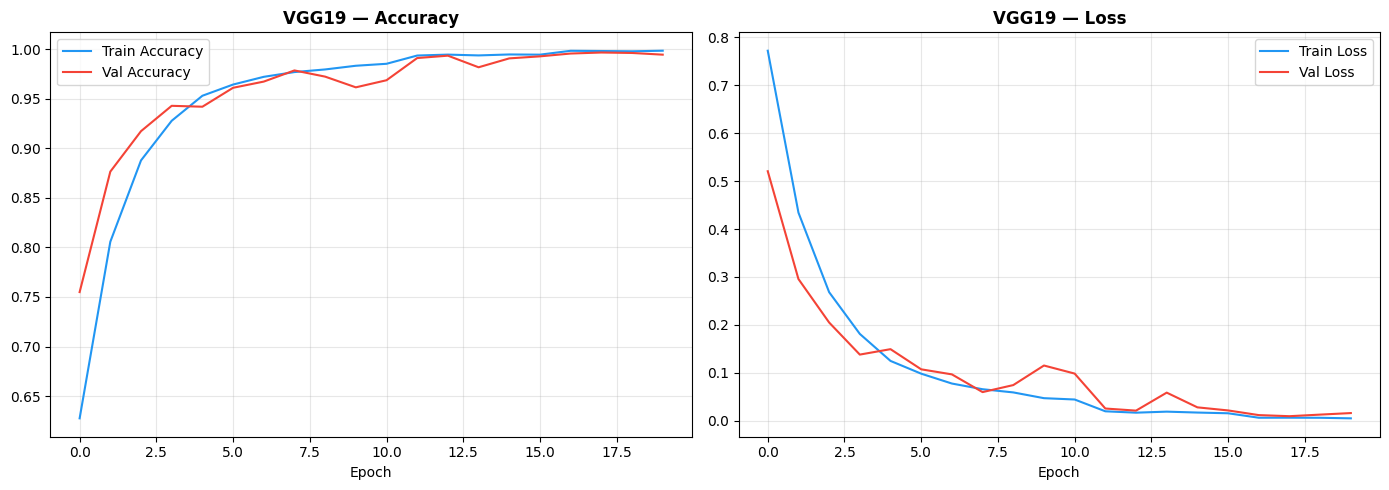


🎯 VGG19 — Test Accuracy: 99.48%  |  Loss: 0.0150

Classification Report:
                  precision    recall  f1-score   support

    MildDemented       1.00      1.00      1.00      2000
ModerateDemented       1.00      1.00      1.00      2000
     NonDemented       0.99      1.00      0.99      2560
VeryMildDemented       1.00      0.98      0.99      2240

        accuracy                           0.99      8800
       macro avg       1.00      0.99      1.00      8800
    weighted avg       0.99      0.99      0.99      8800



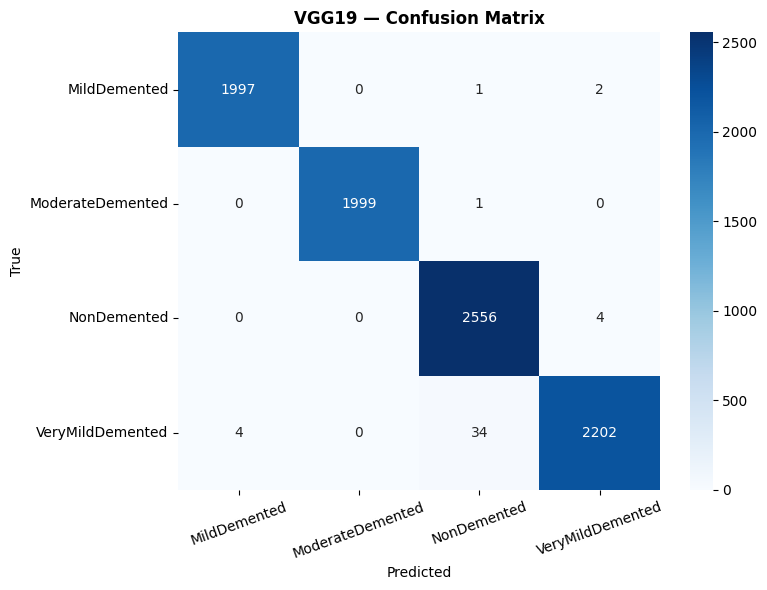

In [16]:
print('🔵 Training VGG19...')
history_vgg19 = vgg19_model.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS, callbacks=get_callbacks('VGG19'), verbose=1
)
print(f'VGG19 saved → {SAVE_DIR}/VGG19_best.keras ✅')
plot_history(history_vgg19, 'VGG19')
acc_vgg19 = evaluate_mri_model(vgg19_model, test_gen, 'VGG19')

## 🟠 MRI Model 2: ResNet50

In [17]:
def build_resnet50(num_classes, lr):
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
    for layer in base.layers[:-10]:
        layer.trainable = False
    for layer in base.layers[-10:]:
        layer.trainable = True
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inputs=base.input, outputs=output)
    model.compile(optimizer=Adam(lr), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

resnet50_model = build_resnet50(NUM_CLASSES, LR)
print(f'ResNet50 built ✅  |  Params: {resnet50_model.count_params():,}')

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet50 built ✅  |  Params: 24,771,204


🟠 Training ResNet50...
Epoch 1/20
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.4122 - loss: 1.3440
Epoch 1: val_accuracy improved from -inf to 0.41443, saving model to /kaggle/working/saved_models/ResNet50_best.keras
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 587s 518ms/step - accuracy: 0.4123 - loss: 1.3439 - val_accuracy: 0.4144 - val_loss: 1.7538 - learning_rate: 1.0000e-04
Epoch 2/20
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.5338 - loss: 1.0333
Epoch 2: val_accuracy did not improve from 0.41443
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 555s 504ms/step - accuracy: 0.5338 - loss: 1.0332 - val_accuracy: 0.3749 - val_loss: 2.7669 - learning_rate: 1.0000e-04
Epoch 3/20
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.5701 - loss: 0.9491
Epoch 3: val_accuracy improved from 0.41443 to 0.42966, saving model to /kaggle/working/saved_models/ResNet50_best.keras
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 569s 517ms/step - accuracy: 0.5701 - loss: 0.9491 - val_accuracy: 0.4297 - val_loss:

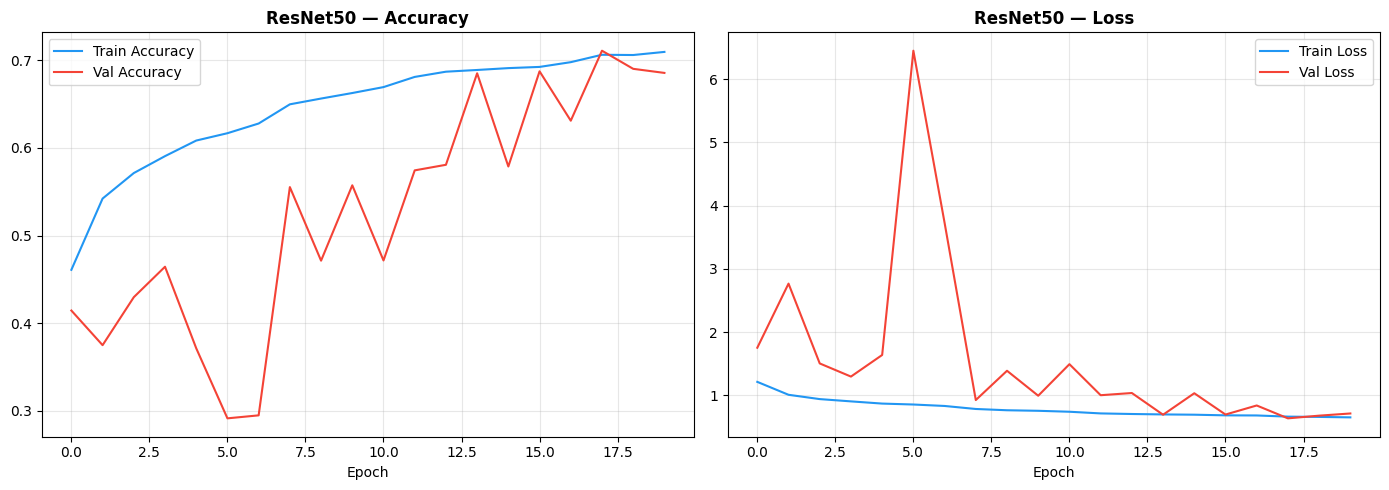


🎯 ResNet50 — Test Accuracy: 75.58%  |  Loss: 0.5520

Classification Report:
                  precision    recall  f1-score   support

    MildDemented       0.78      0.72      0.75      2000
ModerateDemented       0.96      1.00      0.98      2000
     NonDemented       0.73      0.70      0.72      2560
VeryMildDemented       0.59      0.63      0.61      2240

        accuracy                           0.76      8800
       macro avg       0.76      0.76      0.76      8800
    weighted avg       0.76      0.76      0.76      8800



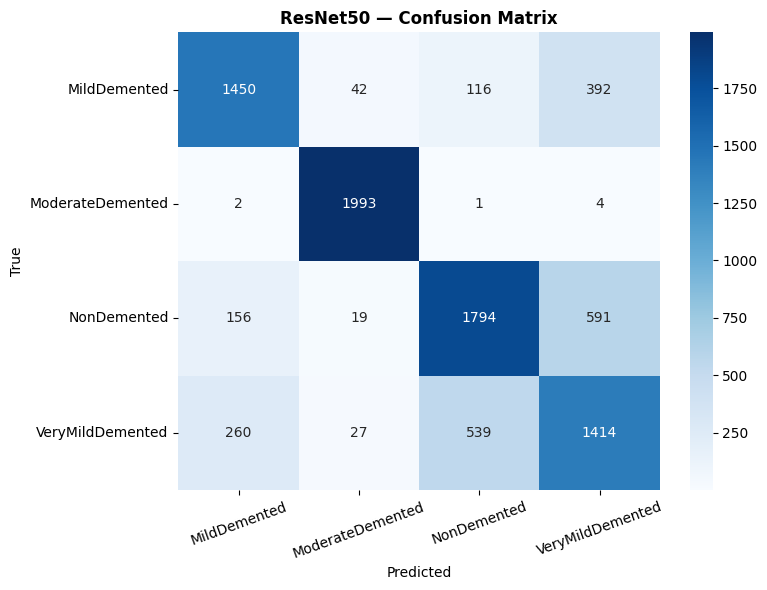

In [18]:
print('🟠 Training ResNet50...')
history_resnet50 = resnet50_model.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS, callbacks=get_callbacks('ResNet50'), verbose=1
)
print(f'ResNet50 saved → {SAVE_DIR}/ResNet50_best.keras ✅')
plot_history(history_resnet50, 'ResNet50')
acc_resnet50 = evaluate_mri_model(resnet50_model, test_gen, 'ResNet50')

## 🟢 MRI Model 3: EfficientNetB0

In [19]:
def build_efficientnet(num_classes, lr):
    base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
    for layer in base.layers[:-20]:
        layer.trainable = False
    for layer in base.layers[-20:]:
        layer.trainable = True
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inputs=base.input, outputs=output)
    model.compile(optimizer=Adam(lr), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

efficientnet_model = build_efficientnet(NUM_CLASSES, LR)
print(f'EfficientNetB0 built ✅  |  Params: {efficientnet_model.count_params():,}')

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB0 built ✅  |  Params: 4,839,847


🟢 Training EfficientNetB0...
Epoch 1/20


2026-04-27 19:53:03.287363: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-27 19:53:03.431073: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-27 19:53:03.789140: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-27 19:53:03.933114: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-27 19:53:04.893167: E external/local_xla/xla/stream_

1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.2585 - loss: 1.8049
Epoch 1: val_accuracy improved from -inf to 0.32705, saving model to /kaggle/working/saved_models/EfficientNetB0_best.keras
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 635s 545ms/step - accuracy: 0.2585 - loss: 1.8048 - val_accuracy: 0.3270 - val_loss: 1.3856 - learning_rate: 1.0000e-04
Epoch 2/20
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.2687 - loss: 1.5386
Epoch 2: val_accuracy did not improve from 0.32705
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 564s 513ms/step - accuracy: 0.2687 - loss: 1.5386 - val_accuracy: 0.2545 - val_loss: 1.3871 - learning_rate: 1.0000e-04
Epoch 3/20
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.2591 - loss: 1.4722
Epoch 3: val_accuracy did not improve from 0.32705
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 572s 520ms/step - accuracy: 0.2591 - loss: 1.4722 - val_accuracy: 0.2545 - val_loss: 1.3806 - learning_rate: 1.0000e-04
Epoch 4/20
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accu

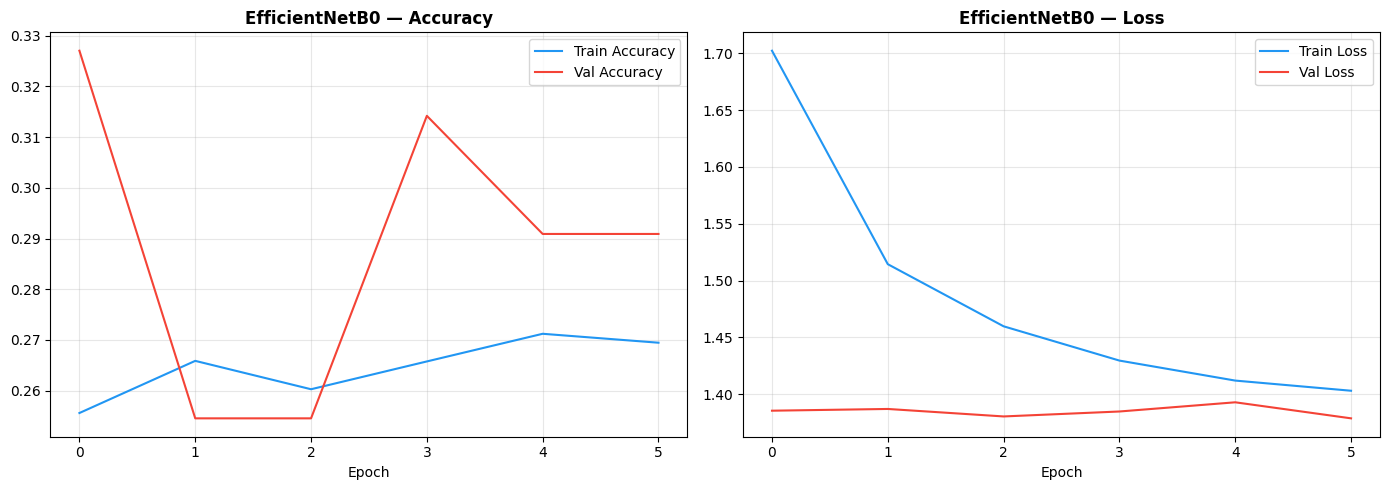


🎯 EfficientNetB0 — Test Accuracy: 30.82%  |  Loss: 1.3859

Classification Report:
                  precision    recall  f1-score   support

    MildDemented       0.00      0.00      0.00      2000
ModerateDemented       0.26      0.82      0.40      2000
     NonDemented       0.42      0.42      0.42      2560
VeryMildDemented       0.00      0.00      0.00      2240

        accuracy                           0.31      8800
       macro avg       0.17      0.31      0.20      8800
    weighted avg       0.18      0.31      0.21      8800



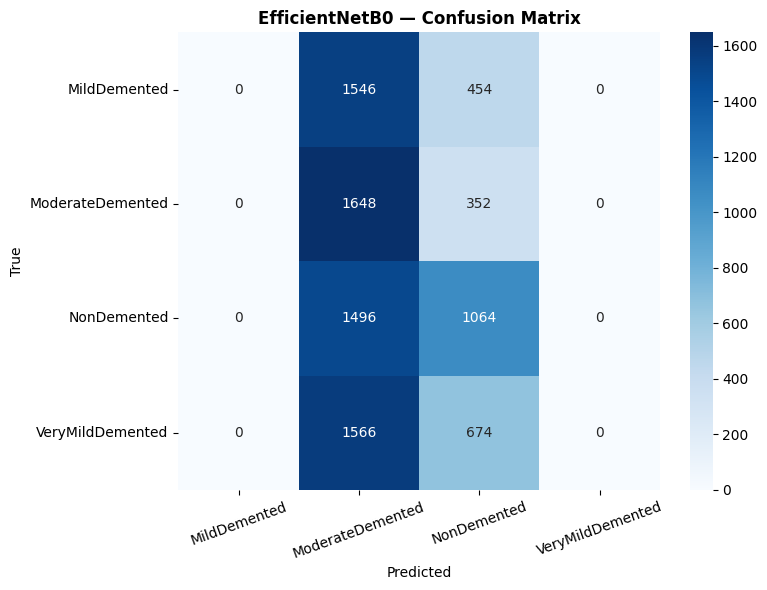

In [20]:
print('🟢 Training EfficientNetB0...')
history_efficientnet = efficientnet_model.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS, callbacks=get_callbacks('EfficientNetB0'), verbose=1
)
print(f'EfficientNetB0 saved → {SAVE_DIR}/EfficientNetB0_best.keras ✅')
plot_history(history_efficientnet, 'EfficientNetB0')
acc_efficientnet = evaluate_mri_model(efficientnet_model, test_gen, 'EfficientNetB0')

## 📊 MRI Models Comparison


   📊 MRI MODELS COMPARISON   
         Model  Accuracy (%)
         VGG19         99.48
      ResNet50         75.58
EfficientNetB0         30.82

🏆 Best MRI Model: VGG19 — 99.48%


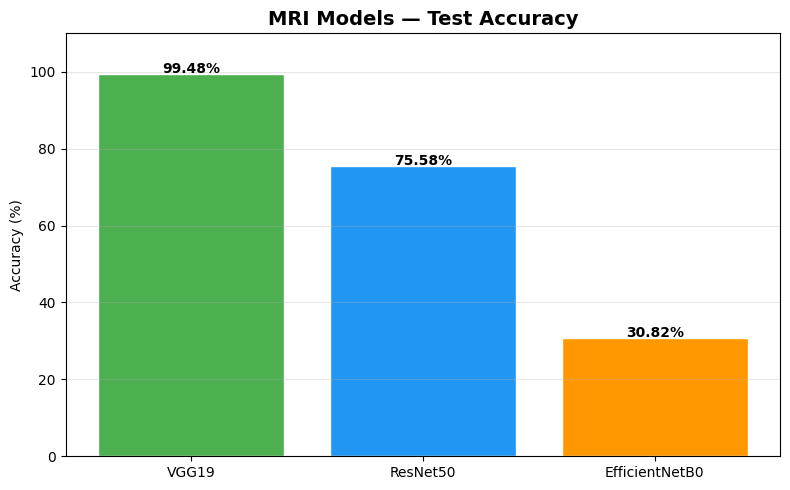

In [ ]:
mri_results = pd.DataFrame({
    'Model'   : ['VGG19', 'ResNet50', 'EfficientNetB0'],
    'Accuracy': [acc_vgg19, acc_resnet50, acc_efficientnet]
})
mri_results['Accuracy (%)'] = (mri_results['Accuracy'] * 100).round(2)
mri_results = mri_results.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print('\n==============================')
print('   📊 MRI MODELS COMPARISON   ')
print('==============================')
print(mri_results[['Model','Accuracy (%)']].to_string(index=False))
print(f'\n🏆 Best MRI Model: {mri_results.iloc[0]["Model"]} — {mri_results.iloc[0]["Accuracy (%)"]:.2f}%')

colors = ['#4CAF50', '#2196F3', '#FF9800']
plt.figure(figsize=(8, 5))
bars = plt.bar(mri_results['Model'], mri_results['Accuracy (%)'], color=colors, edgecolor='white')
for bar, val in zip(bars, mri_results['Accuracy (%)']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.2f}%', ha='center', fontweight='bold')
plt.title('MRI Models — Test Accuracy', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 110)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/mri_comparison.png', dpi=150)
plt.show()

---
# 📊 PART B — CLINICAL DATA MODELS
---

## 🔍 Step 6: Explore Clinical Data

In [ ]:
df = pd.read_csv(CLINICAL_PATH)
print('Shape:', df.shape)
print('\nColumns:', list(df.columns))
df.head(3)

Shape: (2149, 35)

Columns: ['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness', 'Diagnosis', 'DoctorInCharge']


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid


Missing values:
PatientID                    0
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyCompletingTas

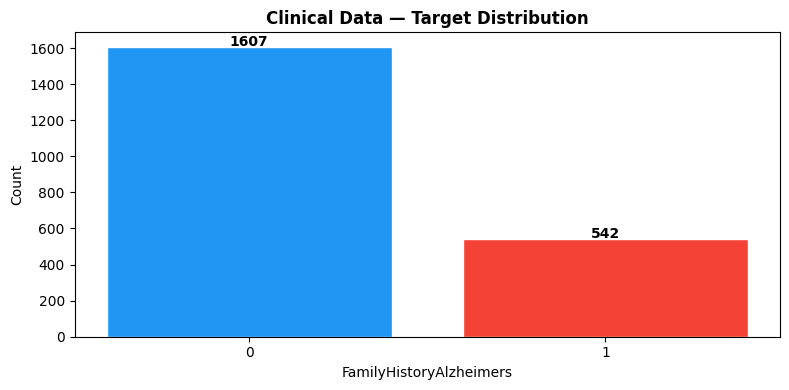

In [ ]:
print('Missing values:')
print(df.isnull().sum())

# Auto-detect target column
target_candidates = [c for c in df.columns
                     if 'diagnosis' in c.lower() or 'label' in c.lower() or 'alzheimer' in c.lower()]
TARGET_COL = target_candidates[0] if target_candidates else 'Diagnosis'
print(f'\nTarget column: "{TARGET_COL}"')
print(df[TARGET_COL].value_counts())

plt.figure(figsize=(8, 4))
counts = df[TARGET_COL].value_counts()
bars = plt.bar(counts.index.astype(str), counts.values,
               color=['#2196F3','#F44336'], edgecolor='white')
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', fontweight='bold')
plt.title('Clinical Data — Target Distribution', fontweight='bold')
plt.xlabel(TARGET_COL)
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('/kaggle/working/clinical_distribution.png', dpi=150)
plt.show()

## ⚙️ Step 7: Preprocess Clinical Data

In [31]:
from sklearn.utils import resample

df_clean = df.copy()

# Drop ID columns
id_cols = [c for c in df_clean.columns if 'id' in c.lower() or 'patient' in c.lower()]
if id_cols:
    df_clean.drop(columns=id_cols, inplace=True)

num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
if TARGET_COL in num_cols: num_cols.remove(TARGET_COL)
if TARGET_COL in cat_cols: cat_cols.remove(TARGET_COL)

for col in num_cols:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)
for col in cat_cols:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    le_dict[col] = le

le_target = LabelEncoder()
y_all = le_target.fit_transform(df_clean[TARGET_COL].astype(str))
X_all = df_clean.drop(columns=[TARGET_COL]).values
feature_names = df_clean.drop(columns=[TARGET_COL]).columns.tolist()
class_names   = list(le_target.classes_)

print(f'Classes: {class_names}')
print(f'Distribution before balancing: {np.bincount(y_all)}')

# =============================================
# BALANCE — Oversample minority class
# =============================================
df_balanced = df_clean.copy()
df_balanced['__target__'] = y_all

majority = df_balanced[df_balanced['__target__'] == 0]
minority = df_balanced[df_balanced['__target__'] == 1]

minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=RANDOM_STATE
)

df_balanced = pd.concat([majority, minority_upsampled])
df_balanced = df_balanced.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

y_all = df_balanced['__target__'].values
X_all = df_balanced.drop(columns=[TARGET_COL, '__target__']).values

print(f'Distribution after balancing : {np.bincount(y_all)}')

# Split & Scale
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE, stratify=y_all
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

joblib.dump(scaler, f'{SAVE_DIR}/clinical_scaler.pkl')
print(f'\nTrain: {X_train.shape}  |  Test: {X_test.shape}')
print('Scaler saved ✅')

Classes: ['0', '1']
Distribution before balancing: [1607  542]
Distribution after balancing : [1607 1607]

Train: (2571, 32)  |  Test: (643, 32)
Scaler saved ✅


## 🛠️ Step 8: Clinical Helper Functions

In [32]:
def evaluate_clinical_model(model, X_test, y_test, model_name, class_names):
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    print(f'\n🎯 {model_name} — Accuracy: {acc*100:.2f}%')
    print(classification_report(y_test, y_pred, target_names=class_names))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} — Confusion Matrix', fontweight='bold')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/{model_name}_cm.png', dpi=150)
    plt.show()
    return acc

def plot_feature_importance(model, feature_names, model_name, top_n=15):
    if hasattr(model, 'feature_importances_'):
        imp = pd.Series(model.feature_importances_, index=feature_names).nlargest(top_n).sort_values()
        plt.figure(figsize=(8, 5))
        imp.plot(kind='barh', color='#2196F3')
        plt.title(f'{model_name} — Top {top_n} Features', fontweight='bold')
        plt.xlabel('Importance')
        plt.tight_layout()
        plt.savefig(f'/kaggle/working/{model_name}_features.png', dpi=150)
        plt.show()

print('Clinical helpers ready ✅')

Clinical helpers ready ✅


## 🌲 Clinical Model 1: Random Forest

🌲 Training Random Forest...
CV Accuracy: 91.29% ± 1.34%
Random Forest saved ✅

🎯 RandomForest — Accuracy: 94.25%
              precision    recall  f1-score   support

           0       0.92      0.98      0.94       322
           1       0.97      0.91      0.94       321

    accuracy                           0.94       643
   macro avg       0.94      0.94      0.94       643
weighted avg       0.94      0.94      0.94       643



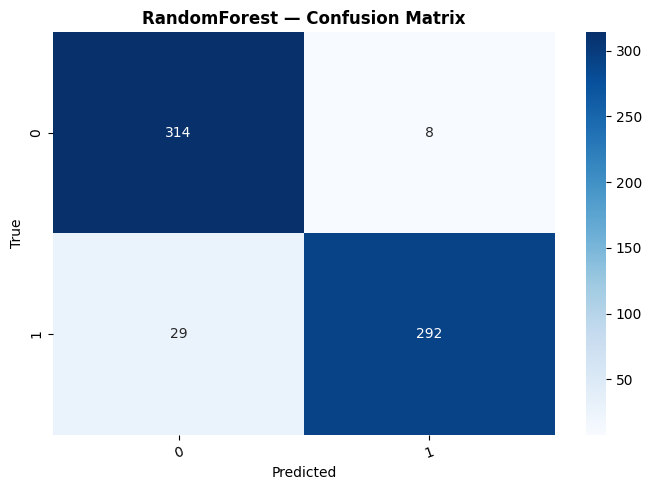

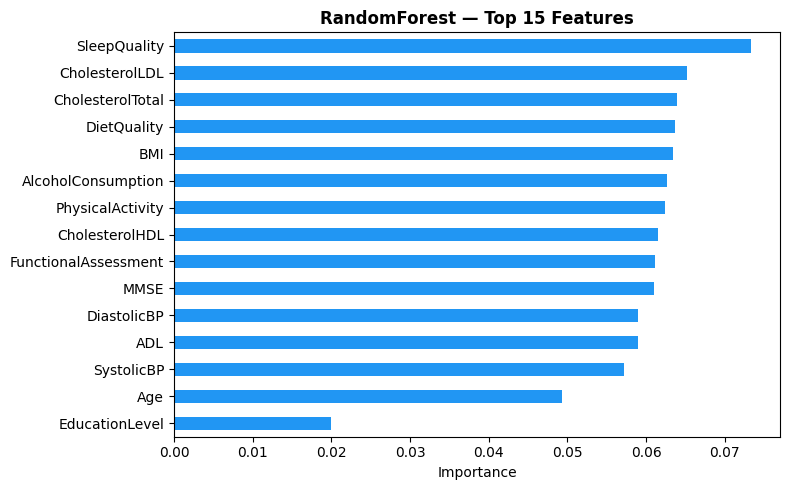

In [33]:
print('🌲 Training Random Forest...')
rf_model = RandomForestClassifier(
    n_estimators=200, min_samples_split=5, min_samples_leaf=2,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

cv_rf = cross_val_score(rf_model, X_train_scaled, y_train,
                        cv=StratifiedKFold(5), scoring='accuracy')
print(f'CV Accuracy: {cv_rf.mean()*100:.2f}% ± {cv_rf.std()*100:.2f}%')

joblib.dump(rf_model, f'{SAVE_DIR}/RandomForest_clinical.pkl')
print('Random Forest saved ✅')

acc_rf = evaluate_clinical_model(rf_model, X_test_scaled, y_test, 'RandomForest', class_names)
plot_feature_importance(rf_model, feature_names, 'RandomForest')

## ⚡ Clinical Model 2: XGBoost

⚡ Training XGBoost...
CV Accuracy: 87.28% ± 1.21%
XGBoost saved ✅

🎯 XGBoost — Accuracy: 88.96%
              precision    recall  f1-score   support

           0       0.91      0.86      0.89       322
           1       0.87      0.92      0.89       321

    accuracy                           0.89       643
   macro avg       0.89      0.89      0.89       643
weighted avg       0.89      0.89      0.89       643



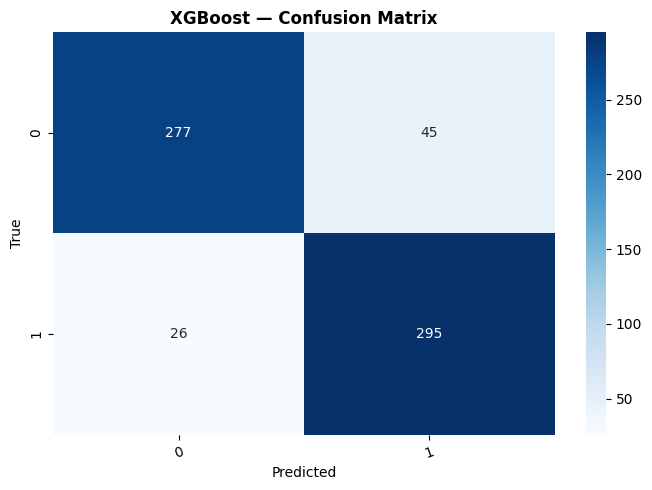

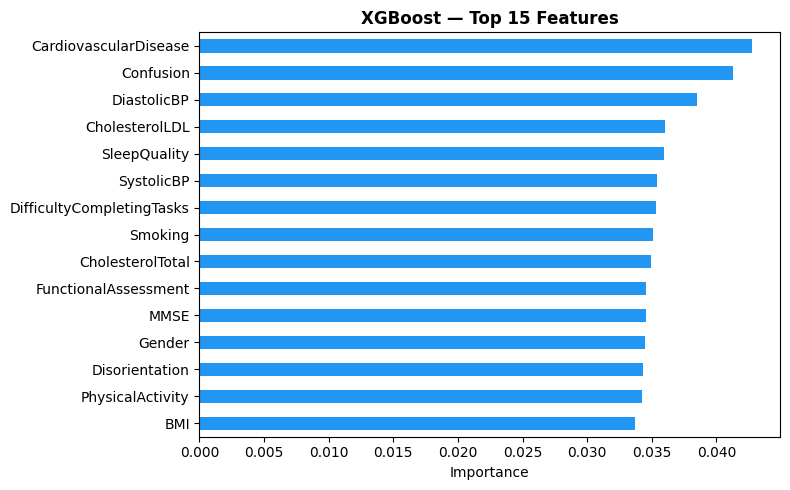

In [34]:
print('⚡ Training XGBoost...')

# Detect number of classes automatically
n_unique = len(np.unique(y_train))

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss' if n_unique == 2 else 'mlogloss',  # ← التعديل هنا
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=False
)

cv_scores_xgb = cross_val_score(xgb_model, X_train_scaled, y_train,
                                cv=StratifiedKFold(5), scoring='accuracy')
print(f'CV Accuracy: {cv_scores_xgb.mean()*100:.2f}% ± {cv_scores_xgb.std()*100:.2f}%')

joblib.dump(xgb_model, f'{SAVE_DIR}/XGBoost_clinical.pkl')
print('XGBoost saved ✅')

acc_xgb = evaluate_clinical_model(xgb_model, X_test_scaled, y_test, 'XGBoost', class_names)
plot_feature_importance(xgb_model, feature_names, 'XGBoost')

## 🔷 Clinical Model 3: 1D-CNN

In [35]:
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn  = X_test_scaled.reshape(X_test_scaled.shape[0],  X_test_scaled.shape[1],  1)
y_train_cat = keras.utils.to_categorical(y_train)
y_test_cat  = keras.utils.to_categorical(y_test)
n_features  = X_train_cnn.shape[1]
n_clin_cls  = y_train_cat.shape[1]

def build_1d_cnn(n_features, n_classes, lr):
    inp = keras.Input(shape=(n_features, 1))
    x = layers.Conv1D(64,  3, activation='relu', padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(256, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    model = keras.Model(inputs=inp, outputs=out)
    model.compile(optimizer=Adam(lr), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

cnn1d_model = build_1d_cnn(n_features, n_clin_cls, LR)
print(f'1D-CNN built ✅  |  Params: {cnn1d_model.count_params():,}')

1D-CNN built ✅  |  Params: 224,258


🔷 Training 1D-CNN...
Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5005 - loss: 0.7270
Epoch 1: val_accuracy improved from -inf to 0.48678, saving model to /kaggle/working/saved_models/1DCNN_clinical_best.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.5006 - loss: 0.7269 - val_accuracy: 0.4868 - val_loss: 0.6943 - learning_rate: 1.0000e-04
Epoch 2/20
71/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5663 - loss: 0.6804
Epoch 2: val_accuracy improved from 0.48678 to 0.50233, saving model to /kaggle/working/saved_models/1DCNN_clinical_best.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5664 - loss: 0.6807 - val_accuracy: 0.5023 - val_loss: 0.6976 - learning_rate: 1.0000e-04
Epoch 3/20
74/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6133 - loss: 0.6499
Epoch 3: val_accuracy did not improve from 0.50233
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6137 - loss: 0.6497 - val_accuracy: 0.5023 - val_loss: 0.7078 - learning_rate: 1.00

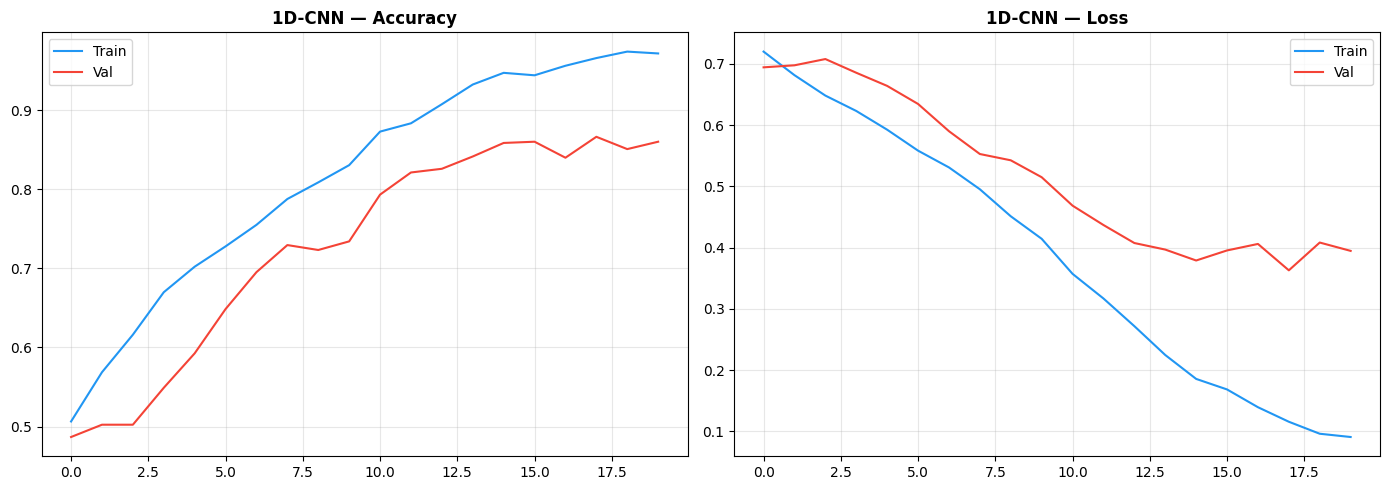


🎯 1D-CNN — Test Accuracy: 86.63%
              precision    recall  f1-score   support

           0       0.90      0.82      0.86       322
           1       0.84      0.91      0.87       321

    accuracy                           0.87       643
   macro avg       0.87      0.87      0.87       643
weighted avg       0.87      0.87      0.87       643



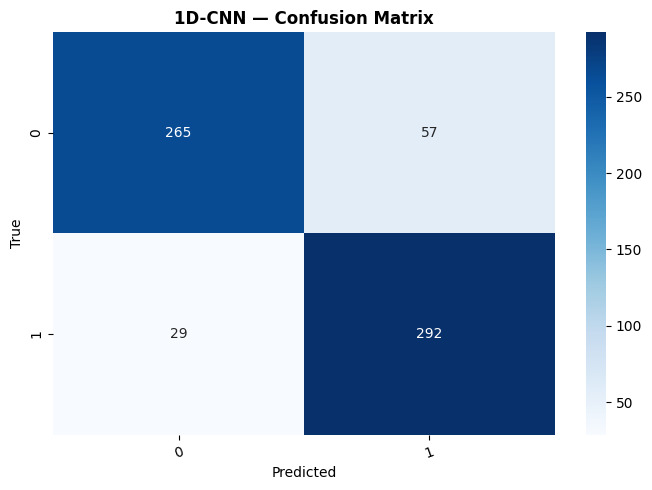

In [36]:
print('🔷 Training 1D-CNN...')
callbacks_1dcnn = [
    ModelCheckpoint(f'{SAVE_DIR}/1DCNN_clinical_best.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-7, verbose=1)
]
history_1dcnn = cnn1d_model.fit(
    X_train_cnn, y_train_cat,
    validation_data=(X_test_cnn, y_test_cat),
    epochs=EPOCHS, batch_size=32,
    callbacks=callbacks_1dcnn, verbose=1
)
print('1D-CNN saved ✅')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (tr, vl), title in zip(
    axes,
    [('accuracy','val_accuracy'), ('loss','val_loss')],
    ['Accuracy', 'Loss']
):
    ax.plot(history_1dcnn.history[tr], label=f'Train', color='#2196F3')
    ax.plot(history_1dcnn.history[vl], label=f'Val',   color='#F44336')
    ax.set_title(f'1D-CNN — {title}', fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/1DCNN_history.png', dpi=150)
plt.show()

y_pred_1dcnn = np.argmax(cnn1d_model.predict(X_test_cnn, verbose=0), axis=1)
acc_1dcnn    = accuracy_score(y_test, y_pred_1dcnn)
print(f'\n🎯 1D-CNN — Test Accuracy: {acc_1dcnn*100:.2f}%')
print(classification_report(y_test, y_pred_1dcnn, target_names=class_names))

cm = confusion_matrix(y_test, y_pred_1dcnn)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('1D-CNN — Confusion Matrix', fontweight='bold')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('/kaggle/working/1DCNN_cm.png', dpi=150)
plt.show()

🔷 Training SVM...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Accuracy: 82.07%
SVM saved ✅

🎯 SVM — Accuracy: 88.18%
              precision    recall  f1-score   support

           0       0.92      0.84      0.88       322
           1       0.85      0.92      0.89       321

    accuracy                           0.88       643
   macro avg       0.88      0.88      0.88       643
weighted avg       0.88      0.88      0.88       643



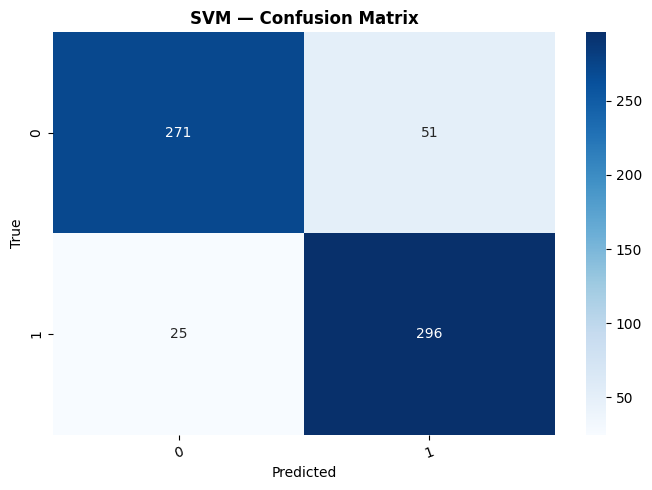

In [43]:
# =============================================
# Clinical Model 4: SVM
# =============================================
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

print('🔷 Training SVM...')

# GridSearch لأفضل parameters
param_grid = {
    'C'      : [0.1, 1, 10, 100],
    'gamma'  : ['scale', 'auto'],
    'kernel' : ['rbf', 'linear']
}

svm_base = SVC(
    probability=True,       # عشان نقدر نطلع probabilities
    class_weight='balanced', # مهم عشان الداتا imbalanced
    random_state=RANDOM_STATE
)

svm_grid = GridSearchCV(
    svm_base,
    param_grid,
    cv=StratifiedKFold(5),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
svm_grid.fit(X_train_scaled, y_train)

svm_model = svm_grid.best_estimator_
print(f'Best params: {svm_grid.best_params_}')
print(f'Best CV Accuracy: {svm_grid.best_score_*100:.2f}%')

# Save
joblib.dump(svm_model, f'{SAVE_DIR}/SVM_clinical.pkl')
print('SVM saved ✅')

acc_svm = evaluate_clinical_model(svm_model, X_test_scaled, y_test, 'SVM', class_names)

## 📊 Clinical Models Comparison

In [44]:
clin_results = pd.DataFrame({
    'Model'   : ['Random Forest', 'XGBoost', '1D-CNN', 'SVM'],
    'Accuracy': [acc_rf, acc_xgb, acc_1dcnn, acc_svm]
})

clin_results['Accuracy (%)'] = (clin_results['Accuracy'] * 100).round(2)
clin_results = clin_results.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print('\n======================================')
print('   📊 CLINICAL MODELS COMPARISON      ')
print('======================================')
print(clin_results[['Model','Accuracy (%)']].to_string(index=False))
print(f'\n🏆 Best Clinical Model: {clin_results.iloc[0]["Model"]} — {clin_results.iloc[0]["Accuracy (%)"]:.2f}%')


   📊 CLINICAL MODELS COMPARISON      
        Model  Accuracy (%)
Random Forest         94.25
      XGBoost         88.96
          SVM         88.18
       1D-CNN         86.63

🏆 Best Clinical Model: Random Forest — 94.25%


---
# 🔗 PART C — FUSION
## دمج MRI Models بـ Weighted Late Fusion
---

In [38]:
# Extract probabilities from each MRI model
print('Extracting MRI model probabilities...')
mri_probas = {}
for name, model in [('VGG19', vgg19_model),
                    ('ResNet50', resnet50_model),
                    ('EfficientNetB0', efficientnet_model)]:
    test_gen.reset()
    mri_probas[name] = model.predict(test_gen, verbose=0)
    print(f'  {name}: {mri_probas[name].shape}')

test_gen.reset()
mri_true       = test_gen.classes
mri_class_lbls = list(test_gen.class_indices.keys())
print(f'\nMRI test samples: {len(mri_true)}')

Extracting MRI model probabilities...
  VGG19: (8800, 4)
  ResNet50: (8800, 4)
  EfficientNetB0: (8800, 4)

MRI test samples: 8800


Individual MRI model accuracies:
  VGG19: 99.48%
  ResNet50: 75.58%
  EfficientNetB0: 30.82%

🔗 Equal-Weight Fusion   : 99.45%
🔗 Accuracy-Weighted Fusion: 99.50%

✅ Best Fusion: Weighted — 99.50%
                  precision    recall  f1-score   support

    MildDemented       1.00      1.00      1.00      2000
ModerateDemented       1.00      1.00      1.00      2000
     NonDemented       0.99      1.00      0.99      2560
VeryMildDemented       1.00      0.98      0.99      2240

        accuracy                           0.99      8800
       macro avg       1.00      1.00      1.00      8800
    weighted avg       1.00      0.99      0.99      8800



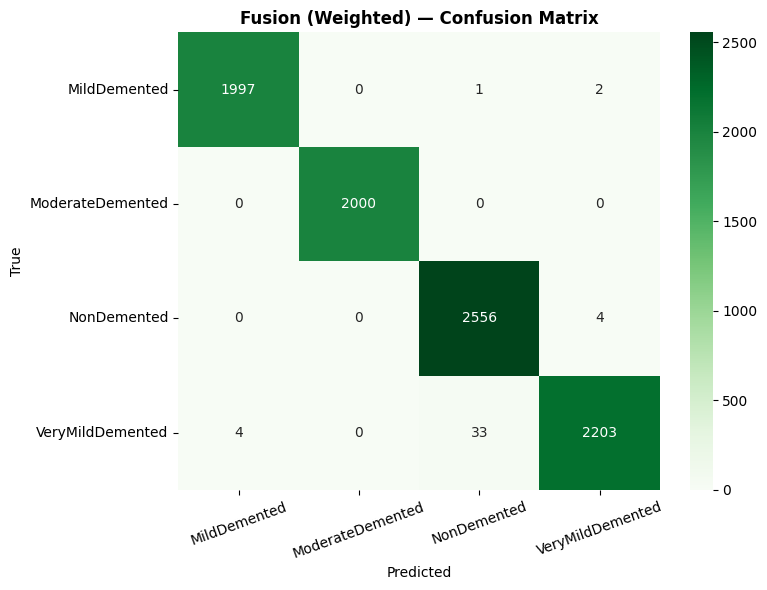

In [39]:
def late_fusion(probas_dict, true_labels, weights=None):
    probas_list = list(probas_dict.values())
    if weights is None:
        weights = [1.0 / len(probas_list)] * len(probas_list)
    fused = np.zeros_like(probas_list[0])
    for proba, w in zip(probas_list, weights):
        fused += w * proba
    y_pred = np.argmax(fused, axis=1)
    acc    = accuracy_score(true_labels, y_pred)
    return fused, y_pred, acc

# Individual accuracies → use as weights
indiv_accs = []
print('Individual MRI model accuracies:')
for name, proba in mri_probas.items():
    a = accuracy_score(mri_true, np.argmax(proba, axis=1))
    indiv_accs.append(a)
    print(f'  {name}: {a*100:.2f}%')

total       = sum(indiv_accs)
acc_weights = [a / total for a in indiv_accs]

# Equal fusion
_, pred_equal,    acc_equal    = late_fusion(mri_probas, mri_true)
# Weighted fusion
_, pred_weighted, acc_weighted = late_fusion(mri_probas, mri_true, weights=acc_weights)

print(f'\n🔗 Equal-Weight Fusion   : {acc_equal*100:.2f}%')
print(f'🔗 Accuracy-Weighted Fusion: {acc_weighted*100:.2f}%')

# Pick best
if acc_weighted >= acc_equal:
    best_fusion_pred  = pred_weighted
    best_fusion_acc   = acc_weighted
    fusion_label      = 'Weighted'
else:
    best_fusion_pred  = pred_equal
    best_fusion_acc   = acc_equal
    fusion_label      = 'Equal'

print(f'\n✅ Best Fusion: {fusion_label} — {best_fusion_acc*100:.2f}%')
print(classification_report(mri_true, best_fusion_pred, target_names=mri_class_lbls))

cm_fusion = confusion_matrix(mri_true, best_fusion_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_fusion, annot=True, fmt='d', cmap='Greens',
            xticklabels=mri_class_lbls, yticklabels=mri_class_lbls)
plt.title(f'Fusion ({fusion_label}) — Confusion Matrix', fontweight='bold')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('/kaggle/working/fusion_cm.png', dpi=150)
plt.show()

---
# 🏆 FINAL SUMMARY — ALL MODELS
---


        🏆 FINAL RESULTS — ALL MODELS          
                   Model      Type  Accuracy (%)
1  MRI Fusion (Weighted)    Fusion         99.50
2                  VGG19       MRI         99.48
3          Random Forest  Clinical         94.25
4                XGBoost  Clinical         88.96
5                 1D-CNN  Clinical         86.63
6               ResNet50       MRI         75.58
7         EfficientNetB0       MRI         30.82

🥇 Best Overall: MRI Fusion (Weighted) — 99.50%


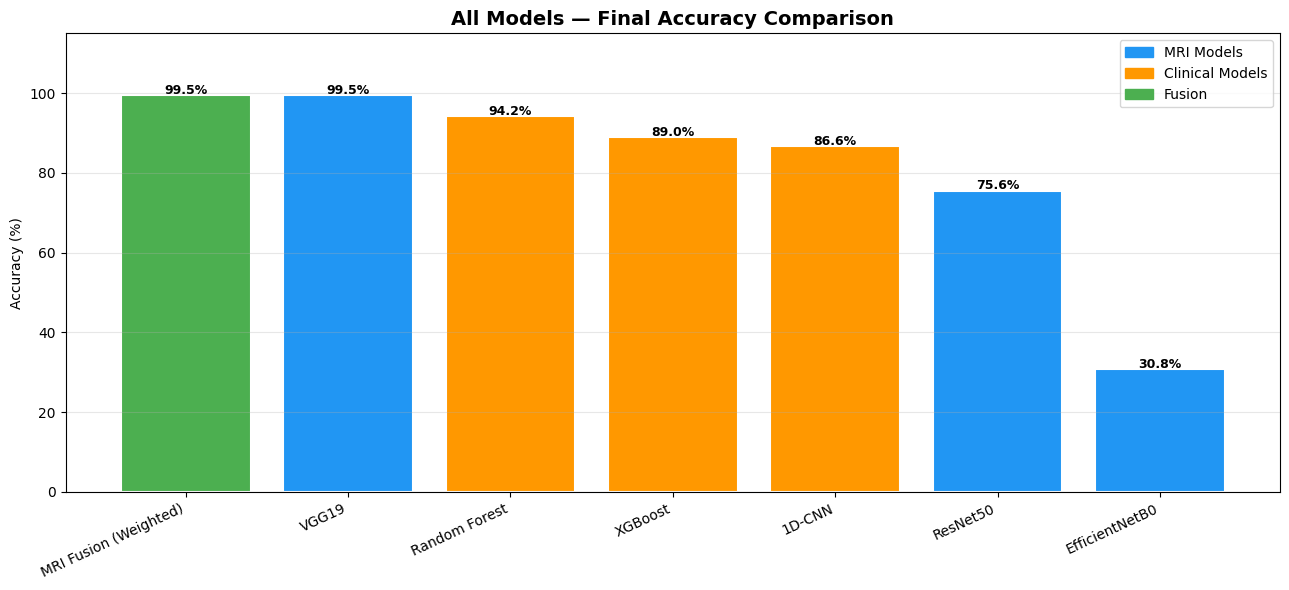

In [40]:
mri_indiv_accs = {n: accuracy_score(mri_true, np.argmax(p, axis=1))
                  for n, p in mri_probas.items()}

all_results = pd.DataFrame([
    {'Model': 'VGG19',          'Type': 'MRI',      'Accuracy': mri_indiv_accs['VGG19']},
    {'Model': 'ResNet50',       'Type': 'MRI',      'Accuracy': mri_indiv_accs['ResNet50']},
    {'Model': 'EfficientNetB0', 'Type': 'MRI',      'Accuracy': mri_indiv_accs['EfficientNetB0']},
    {'Model': 'Random Forest',  'Type': 'Clinical', 'Accuracy': acc_rf},
    {'Model': 'XGBoost',        'Type': 'Clinical', 'Accuracy': acc_xgb},
    {'Model': '1D-CNN',         'Type': 'Clinical', 'Accuracy': acc_1dcnn},
    {'Model': 'SVM',            'Type': 'Clinical', 'Accuracy': acc_svm},   # ← جديد
    {'Model': f'MRI Fusion ({fusion_label})', 'Type': 'Fusion', 'Accuracy': best_fusion_acc},
])

all_results['Accuracy (%)'] = (all_results['Accuracy'] * 100).round(2)
all_results = all_results.sort_values('Accuracy', ascending=False).reset_index(drop=True)
all_results.index += 1

print('\n================================================')
print('        🏆 FINAL RESULTS — ALL MODELS          ')
print('================================================')
print(all_results[['Model','Type','Accuracy (%)']].to_string())
print('================================================')
print(f'\n🥇 Best Overall: {all_results.iloc[0]["Model"]} — {all_results.iloc[0]["Accuracy (%)"]:.2f}%')

color_map = {'MRI': '#2196F3', 'Clinical': '#FF9800', 'Fusion': '#4CAF50'}
colors    = [color_map[t] for t in all_results['Type']]

plt.figure(figsize=(13, 6))
bars = plt.bar(all_results['Model'], all_results['Accuracy (%)'],
               color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, all_results['Accuracy (%)']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
legend_elements = [
    Patch(color='#2196F3', label='MRI Models'),
    Patch(color='#FF9800', label='Clinical Models'),
    Patch(color='#4CAF50', label='Fusion')
]
plt.legend(handles=legend_elements)
plt.title('All Models — Final Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 115)
plt.xticks(rotation=25, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/final_comparison.png', dpi=150)
plt.show()

## 💾 Verify All Saved Files

In [41]:
saved_files = [
    ('VGG19 (MRI)',          f'{SAVE_DIR}/VGG19_best.keras'),
    ('ResNet50 (MRI)',        f'{SAVE_DIR}/ResNet50_best.keras'),
    ('EfficientNetB0 (MRI)', f'{SAVE_DIR}/EfficientNetB0_best.keras'),
    ('Random Forest',        f'{SAVE_DIR}/RandomForest_clinical.pkl'),
    ('XGBoost',               f'{SAVE_DIR}/XGBoost_clinical.pkl'),
    ('1D-CNN',                f'{SAVE_DIR}/1DCNN_clinical_best.keras'),
    ('Scaler',                f'{SAVE_DIR}/clinical_scaler.pkl'),
]

print('\n📂 Saved Models Summary:')
print('-' * 60)
for name, path in saved_files:
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024*1024)
        print(f'  ✅ {name:<25} {size_mb:>6.1f} MB  →  {os.path.basename(path)}')
    else:
        print(f'  ❌ {name:<25} NOT FOUND')
print('-' * 60)


📂 Saved Models Summary:
------------------------------------------------------------
  ✅ VGG19 (MRI)                135.0 MB  →  VGG19_best.keras
  ✅ ResNet50 (MRI)             138.2 MB  →  ResNet50_best.keras
  ✅ EfficientNetB0 (MRI)        35.6 MB  →  EfficientNetB0_best.keras
  ✅ Random Forest               10.1 MB  →  RandomForest_clinical.pkl
  ✅ XGBoost                      0.8 MB  →  XGBoost_clinical.pkl
  ✅ 1D-CNN                       2.6 MB  →  1DCNN_clinical_best.keras
  ✅ Scaler                       0.0 MB  →  clinical_scaler.pkl
------------------------------------------------------------


## 🔮 Predict on a Single MRI Image (Optional)

In [42]:
def predict_single_mri(img_path):
    """Run all MRI models + fusion on a single image."""
    img = load_img(img_path, target_size=IMG_SIZE)
    arr = img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)

    probas = {}
    for name, model in [('VGG19', vgg19_model),
                        ('ResNet50', resnet50_model),
                        ('EfficientNetB0', efficientnet_model)]:
        p = model.predict(arr, verbose=0)[0]
        probas[name] = p
        print(f'[{name}] → {MRI_CLASS_NAMES[np.argmax(p)]} ({p.max()*100:.1f}%)')

    # Fusion
    fused = sum(acc_weights[i] * list(probas.values())[i] for i in range(3))
    print(f'[Fusion] → {MRI_CLASS_NAMES[np.argmax(fused)]} ({fused.max()*100:.1f}%)')

# Test on first image in test set
sample_cls  = sorted(os.listdir(MRI_TEST))[0]
sample_img  = os.listdir(os.path.join(MRI_TEST, sample_cls))[0]
sample_path = os.path.join(MRI_TEST, sample_cls, sample_img)
print(f'Image: {sample_path}\nTrue class: {sample_cls}\n')
predict_single_mri(sample_path)

Image: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented/combined_images/MildDemented/88fbf72d-d02a-4bba-9275-0fa344608916.jpg
True class: MildDemented

[VGG19] → MildDemented (100.0%)
[ResNet50] → MildDemented (43.4%)


2026-04-27 21:00:26.997635: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-27 21:00:27.133014: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-27 21:00:27.898381: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-27 21:00:28.033910: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


[EfficientNetB0] → ModerateDemented (27.9%)
[Fusion] → MildDemented (67.8%)


---
## ✅ Architecture Summary

```
┌──────────────────────┐        ┌───────────────────────┐
│    MRI Images        │        │    Clinical Data       │
│  (224×224 pixels)    │        │  (tabular features)    │
└──────────┬───────────┘        └──────────┬─────────────┘
           │                               │
  ┌────────┴────────┐             ┌────────┴────────┐
  │ VGG19           │             │ Random Forest   │
  │ ResNet50        │             │ XGBoost         │
  │ EfficientNetB0  │             │ 1D-CNN          │
  └────────┬────────┘             └────────┬────────┘
           │                               │
     Weighted Late Fusion           Individual Results
           │
    Final MRI Diagnosis
```

| Branch | Models | Saved Files |
|---|---|---|
| 🖼️ MRI | VGG19, ResNet50, EfficientNetB0 | `*_best.keras` |
| 📊 Clinical | Random Forest, XGBoost, 1D-CNN | `*.pkl` + `*.keras` |
| 🔗 Fusion | Weighted Late Fusion (MRI) | Computed at inference |

In [45]:
import shutil

# اضغط كل الموديلات في zip واحد
shutil.make_archive(
    '/kaggle/working/alzheimer_models',  # اسم الملف
    'zip',
    '/kaggle/working/saved_models'       # الفولدر اللي هيتضغط
)

print('✅ alzheimer_models.zip جاهز للتحميل!')
print('روحي Output ← /kaggle/working ← alzheimer_models.zip')

✅ alzheimer_models.zip جاهز للتحميل!
روحي Output ← /kaggle/working ← alzheimer_models.zip


In [46]:
import shutil

shutil.make_archive(
    '/kaggle/working/all_outputs',  # اسم الـ zip
    'zip',
    '/kaggle/working'               # كل حاجة في working
)

print('✅ all_outputs.zip جاهز!')

✅ all_outputs.zip جاهز!
